#Latihan 1

In [5]:
import pandas as pd
import numpy as np

# --- 1. Data Setup ---
# Data Training
data_training = {
    'Suhu': [10, 25, 15, 20, 18, 20, 22, 24],
    'Angin': [0, 0, 5, 3, 7, 10, 5, 0],
    'Kelas': ['Dingin', 'Panas', 'Dingin', 'Panas', 'Dingin', 'Dingin', 'Panas', 'Panas']
}
df_train = pd.DataFrame(data_training)

# Data Testing point dan K
suhu_test = 16
angin_test = 3
k_value = 4

# --- 2. Calculate Distance (Euclidean) ---
# Selisih Suhu kuadrat: (Suhu_Training - Suhu_Testing)^2
df_train['Selisih suhu'] = (df_train['Suhu'] - suhu_test)**2

# Selisih Angin kuadrat: (Angin_Training - Angin_Testing)^2
df_train['Selisih angin'] = (df_train['Angin'] - angin_test)**2

# Jarak: SQRT(Selisih suhu + Selisih angin)
df_train['Jarak'] = np.sqrt(df_train['Selisih suhu'] + df_train['Selisih angin'])

# --- 3. K-NN Classification (K=4) ---
# Urutkan berdasarkan Jarak dan ambil K=4 data terdekat
df_knn = df_train.sort_values(by='Jarak').head(k_value)

# Lakukan voting: Cari kelas yang paling sering muncul
kelas_terpilih = df_knn['Kelas'].value_counts().index[0]

# --- 4. Hasil Output ---
print("Data Perhitungan (diurutkan berdasarkan jarak terdekat):")
# Tampilkan kolom-kolom penting
print(df_train[['Suhu', 'Angin', 'Kelas', 'Jarak', 'Selisih suhu', 'Selisih angin']].sort_values(by='Jarak'))
print("-" * 50)
print(f"Hasil Klasifikasi untuk Data Testing (Suhu={suhu_test}, Angin={angin_test}) dengan K={k_value}: {kelas_terpilih}")

Data Perhitungan (diurutkan berdasarkan jarak terdekat):
   Suhu  Angin   Kelas     Jarak  Selisih suhu  Selisih angin
2    15      5  Dingin  2.236068             1              4
3    20      3   Panas  4.000000            16              0
4    18      7  Dingin  4.472136             4             16
6    22      5   Panas  6.324555            36              4
0    10      0  Dingin  6.708204            36              9
5    20     10  Dingin  8.062258            16             49
7    24      0   Panas  8.544004            64              9
1    25      0   Panas  9.486833            81              9
--------------------------------------------------
Hasil Klasifikasi untuk Data Testing (Suhu=16, Angin=3) dengan K=4: Dingin


#Latihan 2


/tmp/ipython-input-1333232302.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_true = df['Hasil Sebenarnya'].replace({'Lulus': 1, 'Tidak Lulus': 0})
/tmp/ipython-input-1333232302.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_pred = df['Hasil Prediksi'].replace({'Lulus': 1, 'Tidak Lulus': 0})


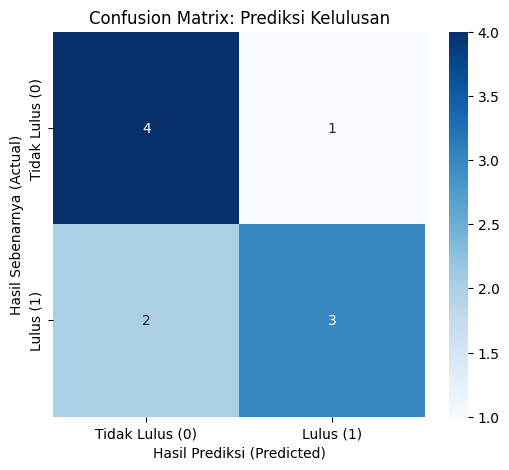

✅ Data Siap Dihitung:
     Nim Hasil Sebenarnya Hasil Prediksi
0  TI001            Lulus          Lulus
1  TI002            Lulus          Lulus
2  TI003            Lulus          Lulus
3  TI004            Lulus    Tidak Lulus
4  TI005            Lulus    Tidak Lulus
5  TI006      Tidak Lulus          Lulus
6  TI007      Tidak Lulus    Tidak Lulus
7  TI008      Tidak Lulus    Tidak Lulus
8  TI009      Tidak Lulus    Tidak Lulus
9  TI010      Tidak Lulus    Tidak Lulus
--------------------------------------------------
📊 Confusion Matrix (CM):
[[4 1]
 [2 3]]

Detail Komponen CM:
True Positive (TP): 3
True Negative (TN): 4
False Positive (FP): 1
False Negative (FN): 2
--------------------------------------------------
📈 Hasil Perhitungan Metrik Performansi:
1. Accuracy (Akurasi): 0.70 atau **70%**
2. Precision (Presisi): 0.75 atau **75%**
3. Recall (Sensitivitas): 0.60 atau **60%**


In [6]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Persiapan Data ---

# Data aktual (sebenarnya) dan data hasil prediksi
data = {
    'Nim': ['TI001', 'TI002', 'TI003', 'TI004', 'TI005', 'TI006', 'TI007', 'TI008', 'TI009', 'TI010'],
    'Hasil Sebenarnya': ['Lulus', 'Lulus', 'Lulus', 'Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus'],
    'Hasil Prediksi': ['Lulus', 'Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus']
}
df = pd.DataFrame(data)

# Konversi string 'Lulus'/'Tidak Lulus' menjadi angka 1/0
y_true = df['Hasil Sebenarnya'].replace({'Lulus': 1, 'Tidak Lulus': 0})
y_pred = df['Hasil Prediksi'].replace({'Lulus': 1, 'Tidak Lulus': 0})

# --- 2. Confusion Matrix ---

# Menghitung Confusion Matrix (sk-learn memberikan hasil dalam format: [[TN, FP], [FN, TP]])
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()

# --- 3. Visualisasi Confusion Matrix ---

# Label untuk sumbu X (Prediksi) dan Y (Aktual)
labels = ['Tidak Lulus (0)', 'Lulus (1)']
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,          # Menampilkan nilai di setiap sel
    fmt='d',             # Format integer (bilangan bulat)
    cmap='Blues',        # Warna peta panas (heatmap)
    xticklabels=labels,  # Label sumbu X (Predicted)
    yticklabels=labels   # Label sumbu Y (Actual)
)
plt.title('Confusion Matrix: Prediksi Kelulusan')
plt.ylabel('Hasil Sebenarnya (Actual)')
plt.xlabel('Hasil Prediksi (Predicted)')
plt.show()

# --- 4. Hitung dan Tampilkan Metrik Performansi ---

print("✅ Data Siap Dihitung:")
print(df)
print("-" * 50)
print("📊 Confusion Matrix (CM):")
print(cm)
print("\nDetail Komponen CM:")
print(f"True Positive (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print("-" * 50)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)

print("📈 Hasil Perhitungan Metrik Performansi:")
print(f"1. Accuracy (Akurasi): {accuracy:.2f} atau **{accuracy*100:.0f}%**")
print(f"2. Precision (Presisi): {precision:.2f} atau **{precision*100:.0f}%**")
print(f"3. Recall (Sensitivitas): {recall:.2f} atau **{recall*100:.0f}%**")

#Latihan 3


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# --- 1. Impor Data dan Preprocessing ---

from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/MACHINELEARNING/PRAKTIKUM/PRAKTIKUM10/DATA/'
df = pd.read_csv(path + "weather_classification_data.csv")

print("✅ Data Awal (5 baris pertama):")
print(df.head())
print("-" * 50)

# Mengidentifikasi fitur (X) dan target (y)
# Fitur (X) = semua kolom kecuali 'Weather Type'
# Target (y) = 'Weather Type'
X = df.drop('Weather Type', axis=1)
y = df['Weather Type']

# Mengkonversi fitur kategorikal menjadi numerik menggunakan One-Hot Encoding (OHE)
X = pd.get_dummies(X, drop_first=True)

# Mengkonversi variabel target kategorikal menjadi numerik (0, 1, 2, ...)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Label yang sudah diencode: ['Cloudy', 'Rainy', 'Sunny'] -> [0, 1, 2]

# Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Jumlah Data Latih: {X_train.shape[0]}")
print(f"Jumlah Data Uji: {X_test.shape[0]}")
print("-" * 50)


# --- 2. Pemodelan dan Pelatihan ---

# 2.1 Model K-NN (K=3, sesuai acuan gambar)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 2.2 Model Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

print("Model K-NN (K=3) dan Decision Tree telah dilatih.")
print("-" * 50)


# --- 3. Evaluasi Model ---

# Prediksi menggunakan kedua model
y_pred_knn = knn.predict(X_test)
y_pred_dtree = dtree.predict(X_test)

# Menghitung Akurasi
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)

print("🎯 Hasil Akurasi Model:")
print(f"1. Akurasi K-NN (K=3): {accuracy_knn:.4f}")
print(f"2. Akurasi Decision Tree: {accuracy_dtree:.4f}")
print("-" * 50)

# Menentukan model terbaik
if accuracy_knn > accuracy_dtree:
    print("🏆 Model K-NN memberikan akurasi yang lebih tinggi.")
elif accuracy_dtree > accuracy_knn:
    print("🏆 Model Decision Tree memberikan akurasi yang lebih tinggi.")
else:
    print("Kedua model memiliki akurasi yang sama.")

# Anda bisa menambahkan visualisasi Confusion Matrix di sini jika diperlukan.

Mounted at /content/drive
✅ Data Awal (5 baris pertama):
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  Spring              1.0   coastal   
4                990.67         1  Winter              2.5  mountain   

  Weather Type  
0        Rainy  
1       Cloudy  
2        Sunny